## Introduction
---
* Import necessary libraries and load data

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../../datasets/raw/spaceship_train.csv')
print(df.shape)

(8693, 14)


* Data Inspection

In [34]:
def inspect_data(df):
    print(f"Columns: \n{df.columns}")
    print(f"Dataframe Info: \n{df.info()}")
    print(f"\nDescriptive Statistics: \n{df.describe().T}")
    print(f"\nMissing Values: \n{df.isnull().sum()}")
    print(f"\nUnique Values: \n{df.nunique()}")
    print(f"\nDuplicated Rows: \n{df.duplicated().sum()}")

In [35]:
inspect_data(df)

Columns: 
Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
d

## Univariate analysis
---
* Target variable

Transported
True     4378
False    4315
Name: count, dtype: int64


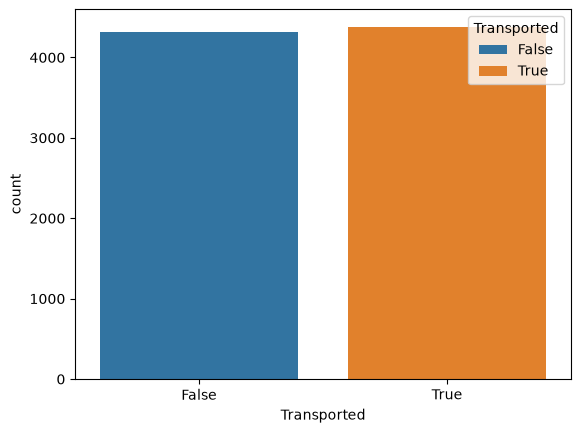

In [21]:
transported = df['Transported'].value_counts()
print(transported)

sns.countplot(data=df, x='Transported', hue='Transported')
plt.show()

*The classes are fairly balanced hence no need for class balancing techniques and accuracy is a reasonable initial evaluation metric.*

* Categorical and Boolean features

In [30]:
grouped = df[["HomePlanet", "CryoSleep", "Destination", "VIP"]]

for col in grouped:
    print(f"\nValue Counts for {col}:")
    print(df[col].value_counts())


Value Counts for HomePlanet:
HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64

Value Counts for CryoSleep:
CryoSleep
False    5439
True     3037
Name: count, dtype: int64

Value Counts for Destination:
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64

Value Counts for VIP:
VIP
False    8291
True      199
Name: count, dtype: int64


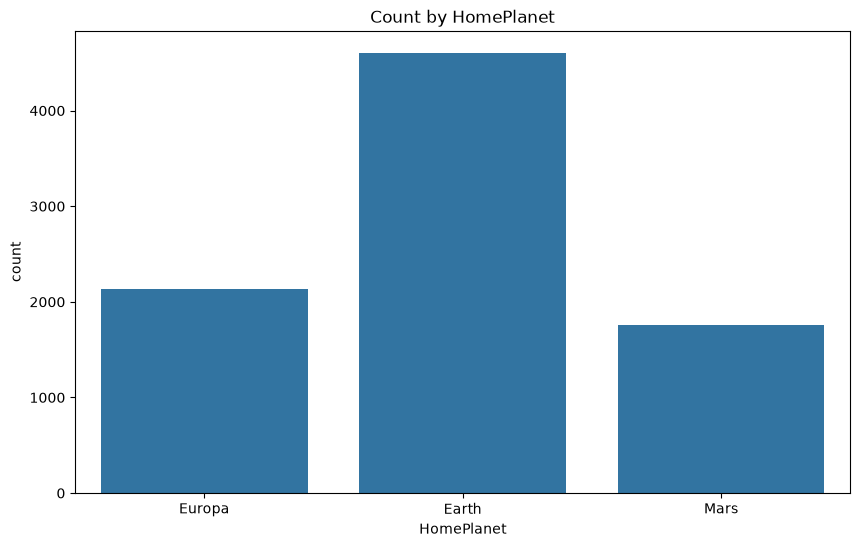

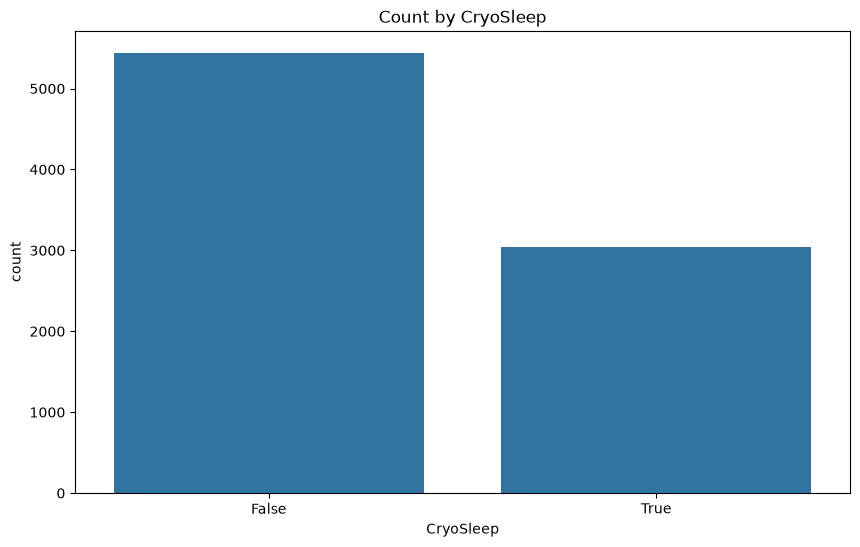

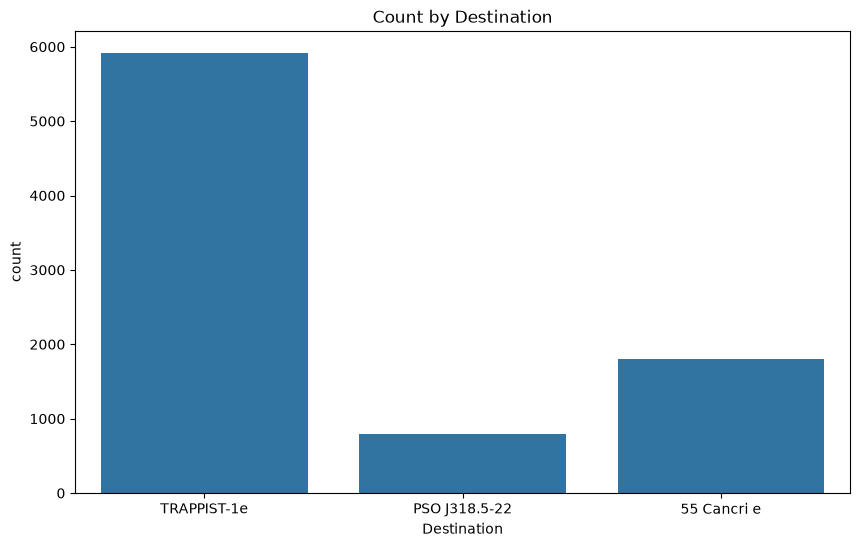

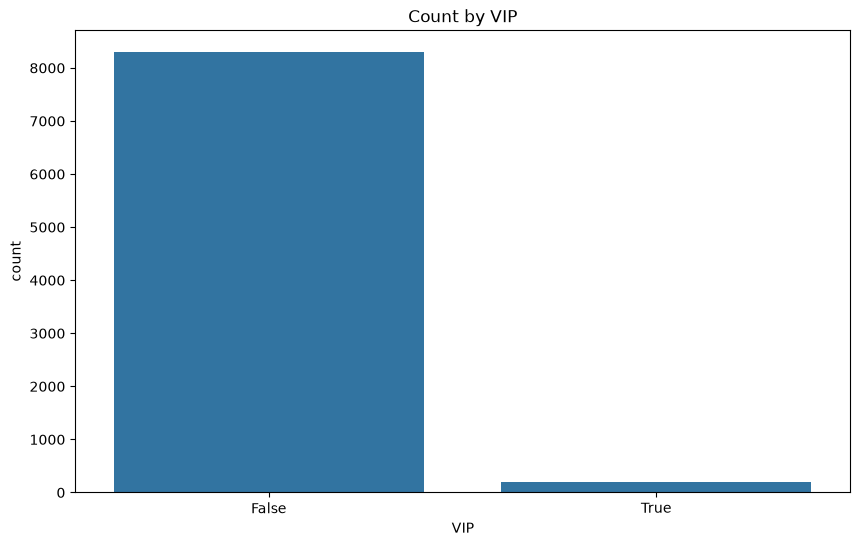

In [31]:
for col in grouped:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f"Count by {col}")
    plt.show()


* Numerical statistics

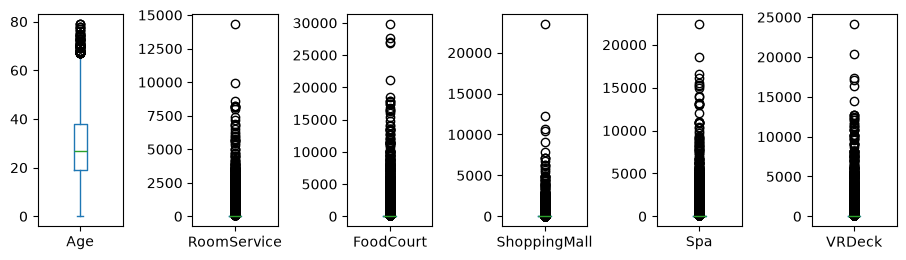

In [22]:
numerical_cols = df.select_dtypes(include="number")

numerical_cols.plot(
    kind="box",
    subplots=True,
    layout=(8, 13),
    figsize=(20, 20)
)

plt.tight_layout()
plt.show()

*Most passengers are young adults which may be associated with the probability of being transported. While when it comes to spending, most passengers didn’t spend much, but a few spent heavily*